In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

1. Đang dò tìm đường dẫn và tải dữ liệu...

[VẼ BIỂU ĐỒ 1: PHÂN BỐ RATING SAO]


/tmp/ipykernel_58/3587113484.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_sample, x='rating', palette='viridis')


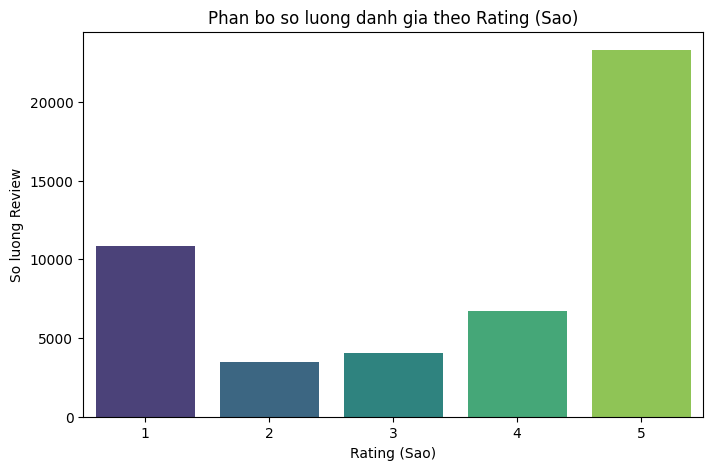


[VẼ BIỂU ĐỒ 2: PHÂN BỐ CẢM XÚC]


/tmp/ipykernel_58/3587113484.py:55: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_sample, x='sentiment', order=['Negative', 'Neutral', 'Positive'], palette='coolwarm')


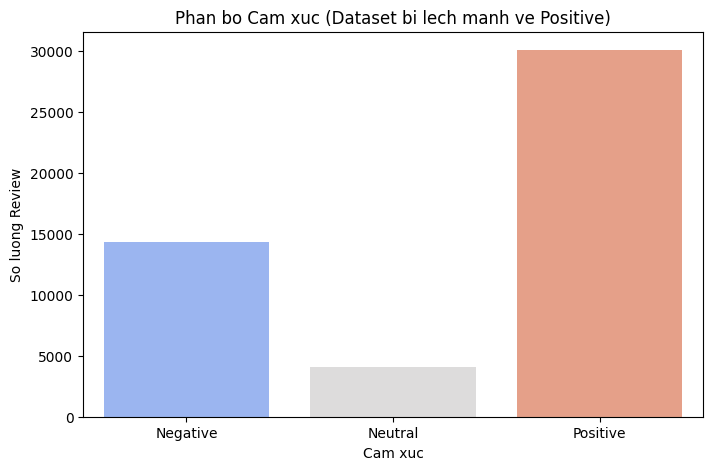


[VẼ BIỂU ĐỒ 3: PHÂN BỐ ĐỘ DÀI CÂU REVIEW]


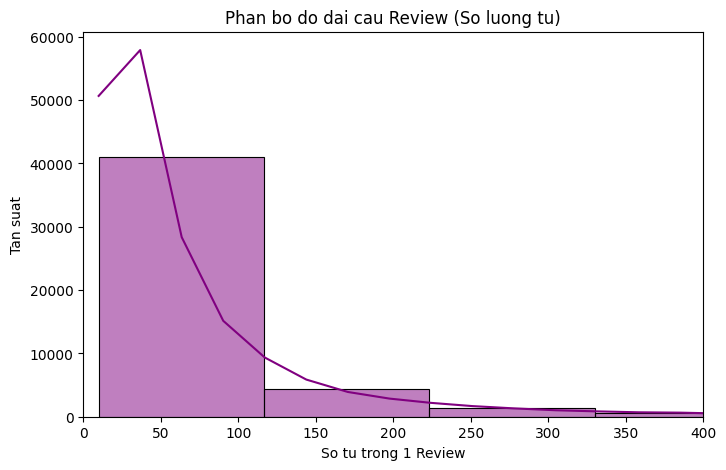


2. Đang chuẩn bị dữ liệu và chạy Baseline Model (Logistic Regression)...

[KẾT QUẢ BASELINE MODEL - LOGISTIC REGRESSION]
Accuracy: 79.38%
F1 Macro: 68.00%

Classification Report:
              precision    recall  f1-score   support

    Negative       0.82      0.77      0.79      2862
     Neutral       0.26      0.54      0.36       810
    Positive       0.95      0.84      0.89      6008

    accuracy                           0.79      9680
   macro avg       0.68      0.72      0.68      9680
weighted avg       0.85      0.79      0.82      9680



In [1]:
import pandas as pd
import numpy as np
import re
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, f1_score

print("1. Đang dò tìm đường dẫn và tải dữ liệu...")
file_path = None
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        if '20191226-reviews.csv' in filename:
            file_path = os.path.join(dirname, filename)
            break

if file_path is None:
    print("LỖI: Trắng tay! Không tìm thấy file. Bác check lại xem đã Add Data chưa nhé!")
else:
    df_raw = pd.read_csv(file_path)
    
    # --- TIỀN XỬ LÝ (KHÓA CHẶT Y HỆT LÚC TRAIN DISTILBERT) ---
    df_sample = df_raw.rename(columns={'body': 'text', 'asin': 'parent_asin', 'name': 'product_name', 'date': 'timestamp'})
    df_sample = df_sample.dropna(subset=['text', 'rating'])

    def clean_text(text):
        text = str(text).lower()
        text = re.sub(r'<.*?>|http\S+|www\S+|[^a-z0-9\s.,!?]', '', text)
        return re.sub(r'\s+', ' ', text).strip()

    df_sample['clean_text'] = df_sample['text'].apply(clean_text)
    # CHÚ Ý: Chỉ lọc bỏ câu ngắn (<10 từ), không lọc câu dài, giống y hệt file cũ!
    df_sample = df_sample[df_sample['clean_text'].apply(lambda x: len(x.split()) >= 10)]

    def get_sentiment(rating):
        if rating >= 4.0: return 'Positive'
        elif rating == 3.0: return 'Neutral'
        else: return 'Negative'
    df_sample['sentiment'] = df_sample['rating'].apply(get_sentiment)

    # ======= PHẦN 1: EDA (VẼ BIỂU ĐỒ BÁO CÁO) =======
    print("\n[VẼ BIỂU ĐỒ 1: PHÂN BỐ RATING SAO]")
    plt.figure(figsize=(8,5))
    sns.countplot(data=df_sample, x='rating', palette='viridis')
    plt.title('Phan bo so luong danh gia theo Rating (Sao)')
    plt.xlabel('Rating (Sao)')
    plt.ylabel('So luong Review')
    plt.show()

    print("\n[VẼ BIỂU ĐỒ 2: PHÂN BỐ CẢM XÚC]")
    plt.figure(figsize=(8,5))
    sns.countplot(data=df_sample, x='sentiment', order=['Negative', 'Neutral', 'Positive'], palette='coolwarm')
    plt.title('Phan bo Cam xuc (Dataset bi lech manh ve Positive)')
    plt.xlabel('Cam xuc')
    plt.ylabel('So luong Review')
    plt.show()

    df_sample['word_count'] = df_sample['clean_text'].apply(lambda x: len(x.split()))
    print("\n[VẼ BIỂU ĐỒ 3: PHÂN BỐ ĐỘ DÀI CÂU REVIEW]")
    plt.figure(figsize=(8,5))
    sns.histplot(df_sample['word_count'], bins=50, color='purple', kde=True)
    plt.title('Phan bo do dai cau Review (So luong tu)')
    plt.xlabel('So tu trong 1 Review')
    plt.ylabel('Tan suat')
    plt.xlim(0, 400) # Cắt view ở 400 từ cho biểu đồ đỡ bị bẹt
    plt.show()

    # ======= PHẦN 2: CHẠY BASELINE MODEL ĐỂ SO SÁNH =======
    print("\n2. Đang chuẩn bị dữ liệu và chạy Baseline Model (Logistic Regression)...")
    X = df_sample['clean_text']
    y = df_sample['sentiment']
    
    # CHIA TẬP TEST/TRAIN (random_state=42 đảm bảo trùng khớp 100% với tập của DistilBERT)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

    # Đếm số lượng từ vựng (TF-IDF)
    tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
    X_train_tfidf = tfidf.fit_transform(X_train)
    X_test_tfidf = tfidf.transform(X_test)

    # Chạy thuật toán Baseline
    baseline_model = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
    baseline_model.fit(X_train_tfidf, y_train)
    y_pred_base = baseline_model.predict(X_test_tfidf)

    print("\n[KẾT QUẢ BASELINE MODEL - LOGISTIC REGRESSION]")
    print(f"Accuracy: {accuracy_score(y_test, y_pred_base)*100:.2f}%")
    print(f"F1 Macro: {f1_score(y_test, y_pred_base, average='macro')*100:.2f}%")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred_base))